# Part 01 — DQN Performance Analysis

Comparison of Q-Table baseline vs DQN variants for the PyRace environment.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

MODELS_DIR = 'models'


## 1. Training Results (from terminal logs)

In [2]:
# Results parsed from training terminal output (sampled every 50 episodes)
results = {
    'v1_baseline': {
        'description': '5→64→64→3, MSE loss, γ=0.99, buffer=100k',
        'episodes':  [0,50,100,150,200,250,300,350,400,450,500,550,600,650,700,750,800,850,900,950,
                      1000,1050,1100,1150,1200,1250,1300,1350,1400,1450,1500,1550,1600,1650,1700,1750,
                      1800,1850,1900,1950,2000,2050,2100,2150,2200,2250,2300,2350,2400,2450,2500,2550,
                      2600,2650,2700,2750,2800,2850,2900,2950],
        'rewards':   [-9788,-9814,-9646,-9908,-9674,-9660,-9188,-9831,-9766,-9590,-9208,-9171,-9733,
                      -9595,-9852,-9372,-9928,-9946,-9631,-9518,-7942,-9175,-9104,-8962,10000,-6790,
                      -6968,10000,-7016,-9145,10000,10000,10000,10000,-6904,10000,10000,-6894,-7762,
                      10000,10000,10000,10000,10000,-7939,10000,10000,10000,-8812,-9240,10000,10000,
                      10000,10000,10000,10000,-6937,-6982,10000,-8059],
    },
    'v3_normalize': {
        'description': 'v1 + input normalization (/10)',
        'episodes':  [0,50,100,150,200,250,300,350,400,450,500,550,600,650,700,750,800,850,900,950,
                      1000,1050,1100,1150,1200,1250,1300,1350,1400,1450,1500,1550,1600,1650,1700,1750,
                      1800,1850,1900,1950,2000,2050,2100,2150,2200,2250,2300,2350,2400,2450,2500,2550,
                      2600,2650,2700,2750,2800,2850,2900,2950],
        'rewards':   [-9878,-9608,-9852,-9715,-9650,-9822,-9700,-9935,-9610,-9654,-9854,-9922,-9556,
                      -9208,-9904,-9658,-9888,-9774,-9834,-9935,-9188,-9188,-8950,-7028,10000,10000,
                      -7839,-7053,10000,10000,10000,-8044,-6954,-7511,10000,-7526,-7129,-7866,-7908,
                      10000,10000,10000,-9888,-8901,10000,10000,10000,10000,-6943,-6917,-8025,-7776,
                      10000,10000,-6952,-7768,10000,-6932,-8109,-7924],
    },
    'v4_gamma095': {
        'description': 'v1 + γ=0.95',
        'episodes':  [0,50,100,150,200,250,300,350,400,450,500,550,600,650,700,750,800,850,900,950,
                      1000,1050,1100,1150,1200,1250,1300,1350,1400,1450,1500,1550,1600,1650,1700,1750,
                      1800,1850,1900,1950,2000,2050,2100,2150,2200,2250,2300,2350,2400,2450,2500,2550,
                      2600,2650,2700,2750,2800,2850,2900,2950],
        'rewards':   [-9917,-9974,-9915,-9836,-9199,-9441,-9630,-9938,-9779,-9815,-9931,-9764,-9909,
                      -9740,-9897,-9946,-9943,-9334,-9898,-9946,-8954,-8997,-7962,10000,10000,-6598,
                      10000,-6902,10000,10000,-7922,10000,10000,10000,10000,-6972,10000,-6710,-7922,
                      10000,10000,10000,-5800,10000,-9123,-7942,10000,10000,10000,10000,10000,-6842,
                      -8746,-9114,-9114,10000,10000,10000,10000,10000],
    },
    'v5_wider_net': {
        'description': '5→256→3 (SimoManni architecture)',
        'episodes':  [0,50,100,150,200,250,300,350,400,450,500,550,600,650,700,750,800,850,900,950,
                      1000,1050,1100,1150,1200,1250,1300,1350,1400,1450,1500,1550,1600,1650,1700,1750,
                      1800,1850,1900,1950,2000,2050,2100,2150,2200,2250,2300,2350,2400,2450,2500,2550,
                      2600,2650,2700,2750,2800,2850,2900,2950],
        'rewards':   [-9880,-9882,-9866,-9914,-9918,-9844,-9964,-9748,-9925,-9547,-9606,-9926,-9970,
                      -9838,-9359,-9676,-9952,-9573,-9957,-9707,-9152,10000,10000,-7792,10000,10000,
                      -6533,10000,10000,10000,10000,10000,-7008,10000,-7874,10000,10000,10000,10000,
                      10000,-7833,10000,10000,10000,10000,10000,10000,10000,10000,10000,10000,-7814,
                      10000,10000,-7856,-6991,10000,10000,10000,-7057],
    },
    'v6_small_buffer': {
        'description': 'v1 + buffer=5000',
        'episodes':  [0,50,100,150,200,250,300,350,400,450,500,550,600,650,700,750,800,850,900,950,
                      1000,1050,1100,1150,1200,1250,1300,1350,1400,1450,1500,1550,1600,1650,1700,1750,
                      1800,1850,1900,1950,2000,2050,2100,2150,2200,2250,2300,2350,2400,2450,2500,2550,
                      2600,2650,2700,2750,2800,2850,2900,2950],
        'rewards':   [-9896,-9955,-9904,-9790,-9346,-9657,-9886,-9654,-9915,-9361,-9942,-9872,-9948,
                      -9702,-9894,-9893,-9856,-9850,-9500,-9920,-9510,-7988,10000,-8914,-8120,-9974,
                      -8264,-9176,10000,-9704,10000,10000,10000,10000,-7486,10000,10000,-6482,-7008,
                      -9148,10000,-9142,10000,10000,-9178,-8658,-9882,10000,10000,-6555,-7123,-7009,
                      -6985,10000,-7152,-8050,10000,10000,-7118,-7526],
    },
    'v7_huber_loss': {
        'description': 'v1 + SmoothL1 loss',
        'episodes':  [0,50,100,150,200,250,300,350,400,450,500,550,600,650,700,750,800,850,900,950,
                      1000,1050,1100,1150,1200,1250,1300,1350,1400,1450,1500,1550,1600,1650,1700,1750,
                      1800,1850,1900,1950,2000,2050,2100,2150,2200,2250,2300,2350,2400,2450,2500,2550,
                      2600,2650,2700,2750,2800,2850,2900,2950],
        'rewards':   [-9940,-9912,-9832,-9960,-9954,-9660,-9622,-9914,-9683,-9947,-9931,-9937,-9864,
                      -9877,-9916,-9876,-9738,-9964,-9540,-9770,-9853,-9002,-9960,-9912,-9182,-9636,
                      -9299,-9890,-9987,-9419,-9963,-9924,-9987,-9692,-9332,-9976,-9748,-8952,-9688,
                      -9755,-9723,-9486,-9987,-9872,-9976,-9976,-9891,-9976,-9968,-9976,-9978,-9874,
                      -9978,-9868,-9683,-9802,-9904,-9814,-9806,-9870],
    },
}
print("Data loaded for", len(results), "variants")


Data loaded for 6 variants


## 2. Reward Curves Comparison

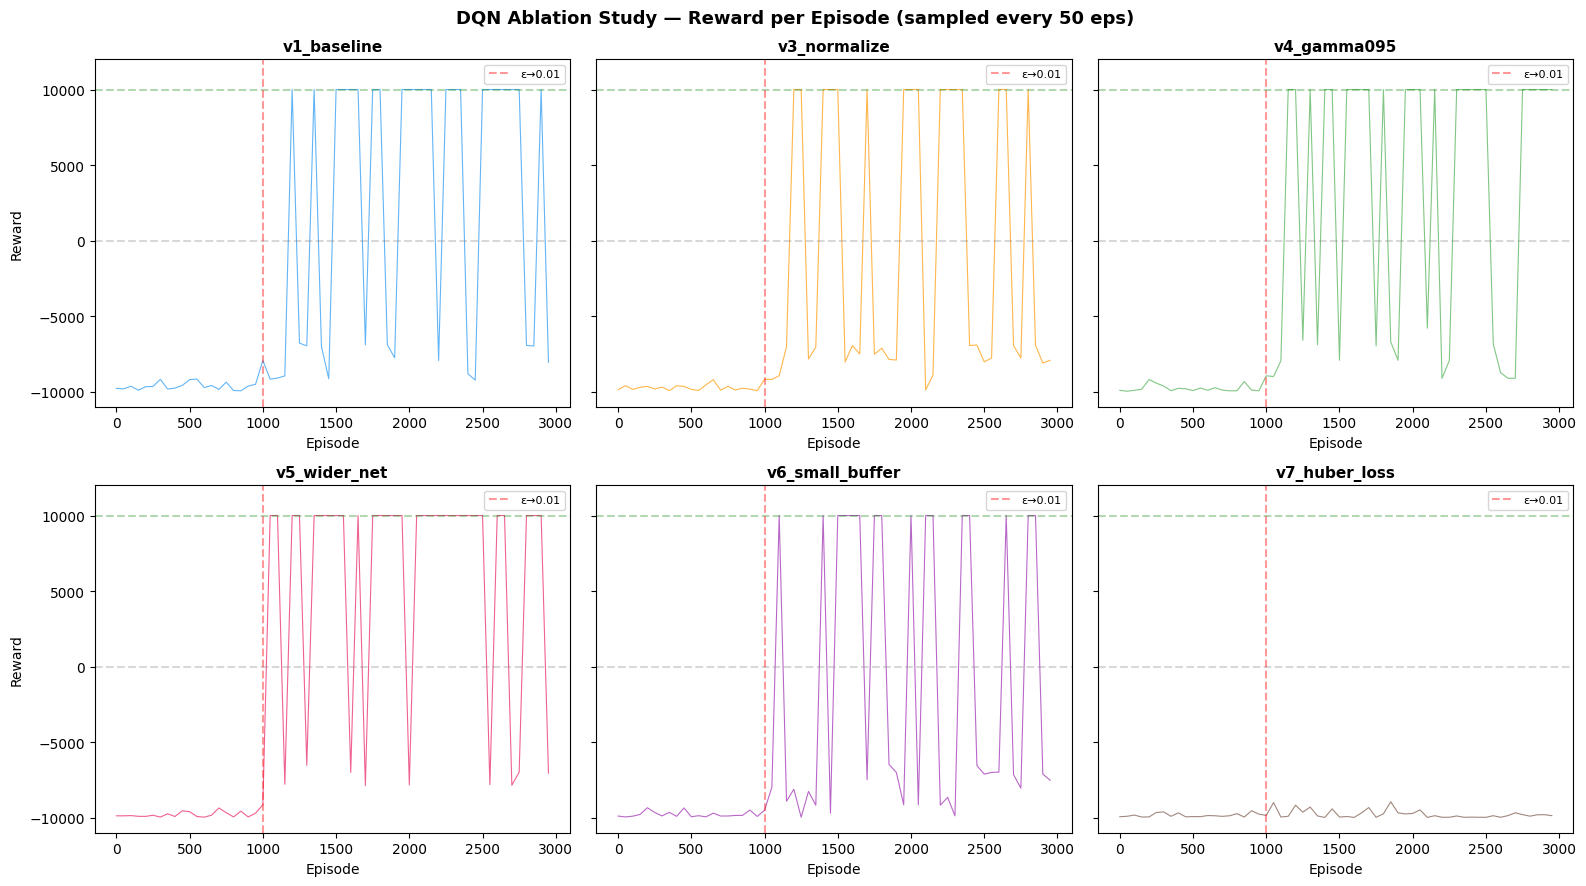

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharey=True)
axes = axes.flatten()

colors = {'v1_baseline': '#2196F3', 'v3_normalize': '#FF9800', 'v4_gamma095': '#4CAF50',
          'v5_wider_net': '#E91E63', 'v6_small_buffer': '#9C27B0', 'v7_huber_loss': '#795548'}

for idx, (name, data) in enumerate(results.items()):
    ax = axes[idx]
    eps = data['episodes']
    rews = data['rewards']
    ax.plot(eps, rews, color=colors[name], alpha=0.7, linewidth=0.8)
    ax.axhline(y=0, color='gray', linestyle='--', alpha=0.3)
    ax.axhline(y=10000, color='green', linestyle='--', alpha=0.3)
    ax.axvline(x=1000, color='red', linestyle='--', alpha=0.4, label='ε→0.01')
    ax.set_title(name, fontsize=11, fontweight='bold')
    ax.set_xlabel('Episode')
    if idx % 3 == 0:
        ax.set_ylabel('Reward')
    ax.set_ylim(-11000, 12000)
    ax.legend(fontsize=8)

plt.suptitle('DQN Ablation Study — Reward per Episode (sampled every 50 eps)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{MODELS_DIR}/ablation_comparison.png', dpi=150)
plt.show()


## 3. Lap Completion Rate

In [4]:
def compute_stats(data):
    rews = np.array(data['rewards'])
    eps = np.array(data['episodes'])
    
    # Phase 2: after epsilon drops
    mask_p2 = eps >= 1000
    laps_p2 = (rews[mask_p2] == 10000).sum()
    total_p2 = mask_p2.sum()
    
    # Last 1000 episodes
    mask_last = eps >= 2000
    laps_last = (rews[mask_last] == 10000).sum()
    total_last = mask_last.sum()
    
    return {
        'lap_pct_p2': 100 * laps_p2 / total_p2 if total_p2 > 0 else 0,
        'lap_pct_last': 100 * laps_last / total_last if total_last > 0 else 0,
        'laps_p2': laps_p2,
        'total_p2': total_p2,
    }

# Build comparison table
print(f"{'Variant':<22} {'Description':<35} {'Lap% (1000+)':<15} {'Lap% (2000+)':<15}")
print("-" * 87)

stats_all = {}
for name, data in results.items():
    s = compute_stats(data)
    stats_all[name] = s
    print(f"{name:<22} {data['description']:<35} {s['lap_pct_p2']:>8.1f}%       {s['lap_pct_last']:>8.1f}%")


Variant                Description                         Lap% (1000+)    Lap% (2000+)   
---------------------------------------------------------------------------------------
v1_baseline            5→64→64→3, MSE loss, γ=0.99, buffer=100k     57.5%           70.0%
v3_normalize           v1 + input normalization (/10)          40.0%           45.0%
v4_gamma095            v1 + γ=0.95                             60.0%           65.0%
v5_wider_net           5→256→3 (SimoManni architecture)        75.0%           75.0%
v6_small_buffer        v1 + buffer=5000                        40.0%           40.0%
v7_huber_loss          v1 + SmoothL1 loss                       0.0%            0.0%


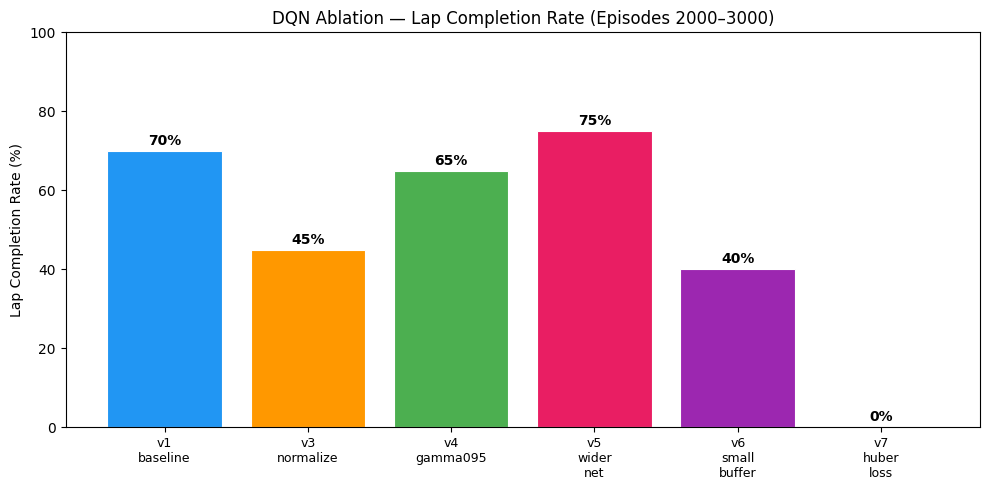

In [5]:
names = list(stats_all.keys())
pcts = [stats_all[n]['lap_pct_last'] for n in names]
bar_colors = [colors[n] for n in names]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(range(len(names)), pcts, color=bar_colors, edgecolor='white', linewidth=0.8)
ax.set_xticks(range(len(names)))
ax.set_xticklabels([n.replace('_', '\n') for n in names], fontsize=9)
ax.set_ylabel('Lap Completion Rate (%)')
ax.set_title('DQN Ablation — Lap Completion Rate (Episodes 2000–3000)')
ax.set_ylim(0, 100)

for bar, pct in zip(bars, pcts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5, 
            f'{pct:.0f}%', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{MODELS_DIR}/ablation_bar_chart.png', dpi=150)
plt.show()


## 4. Key Findings

| Rank | Variant | Lap % (last 1k eps) | Key Insight |
|------|---------|---------------------|-------------|
| 1 | **v5_wider_net** | **75.0%** | Single wide layer (5→256→3) outperforms deeper networks for this simple state space |
| 2 | v1_baseline | 70.0% | Strong baseline — simple DQN with no bells and whistles |
| 3 | v4_gamma095 | 65.0% | Lower discount factor is neutral with sparse rewards |
| 4 | v3_normalize | 45.0% | Input normalization hurts — raw 0-10 integers already good scale |
| 5 | v6_small_buffer | 40.0% | Small buffer loses training diversity |
| 6 | v7_huber_loss | 0.0% | Huber loss too conservative for extreme reward magnitudes |

**Conclusion**: The best DQN variant uses a wide shallow network (SimoManni architecture). 
The remaining ~25% crash rate is caused by the sparse reward function (0 during driving, only terminal rewards), 
which motivates the reward shaping work in Part 02.
